#

# Лабораторная работа 4. Кластеризация

## Описание работы
**Цель работы:** изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

**Постановка задачи:**

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

1. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

1. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

1. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

1. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

1. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

## Ход работы

**О датасете:** Датасет содержит наблюдений объектов (рыб) различных видов и 3 количественных признака: длина (length), масса (weight) и соотношение массы к длине (w_l_ratio). Первоначально в наборе данных также присутствовал признак species, указывающий на вид рыбы, который использовался только для оценки качества кластеризации, но не участвовал в самом процессе кластеризации.

Признаки:

1. Длина рыбы (length) — измеряется в сантиметрах. Значения колеблются от примерно 5 см до 35 см. Этот признак позволяет различать рыбу по размеру и является одним из ключевых факторов для кластеризации.

1. Масса рыбы (weight) — измеряется в килограммах.

1. Соотношение массы к длине (w_l_ratio) — безразмерный показатель, показывающий “плотность” или упитанность рыбы. Он помогает отделять рыбу одного размера, но различной комплекции.

### Анализ данных

Сначала датасет и выведем первые пять строк.


In [227]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('datasets/fish_data.csv')
data



,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31
...,...,...,...,...
4075,Sillaginopsis panijus,30.56,6.12,0.20
4076,Sillaginopsis panijus,29.66,6.11,0.21
4077,Sillaginopsis panijus,32.81,6.25,0.19
4078,Sillaginopsis panijus,29.78,6.11,0.21


Удалилим класс рыб для того, чтобы использовать кластеризацию, но также сохраним классы для подсчета внешних метрик

In [228]:
from sklearn.preprocessing import LabelEncoder

y_true = data['species']

le = LabelEncoder()

y_true = le.fit_transform(y_true)

data.drop(columns='species', axis=1, inplace=True)


Далее узнаем тип признаков

In [229]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   length     4080 non-null   float64
 1   weight     4080 non-null   float64
 2   w_l_ratio  4080 non-null   float64
dtypes: float64(3)
memory usage: 95.8 KB


Как видим будем работать только с вещественными переменнами

Также проверим на наличие пропусков:

In [230]:
data.isna().sum()

length       0
weight       0
w_l_ratio    0
dtype: int64

Пропуски отсутствуют, поэтому дополнительная очистка данных по этому признаку не требовалась. Все записи корректны и могут быть использованы для анализа и кластеризации, что обеспечивает полноту и достоверность дальнейших вычислений.

Далее выведем основные статистические характеристики каждого числового признака после удаления признака species и очистки данных.

In [231]:
data.describe().round(2)

,length,weight,w_l_ratio
count,4080.00,4080.00,4080.00
mean,17.35,3.74,0.25
std,7.11,1.04,0.12
min,6.36,2.05,0.08
25%,11.33,3.07,0.17
50%,17.35,3.31,0.19
75%,22.58,4.10,0.34
max,33.86,6.29,0.64


Датасет демонстрирует значительное разнообразие рыб по длине и массе, при этом длина варьируется от 6.36 до 33.86 см со средним значением 17.35 см, а масса — от 2.05 до 6.29 кг со средним 3.74 кг, что отражает широкий разброс биологических характеристик; показатель w_l_ratio, отражающий соотношение массы к длине, имеет меньший диапазон (0.08–0.64) и среднее 0.25, показывая различия в упитанности рыб; такое распределение признаков требует их масштабирования перед применением алгоритмов кластеризации для корректного расчёта расстояний между объектами.

Постоим гистограммы для того, чтобы  узнать как распределены основные количественные признаки датасета.

array([[<Axes: title={'center': 'length'}>,
        <Axes: title={'center': 'weight'}>],
       [<Axes: title={'center': 'w_l_ratio'}>, <Axes: >]], dtype=object)

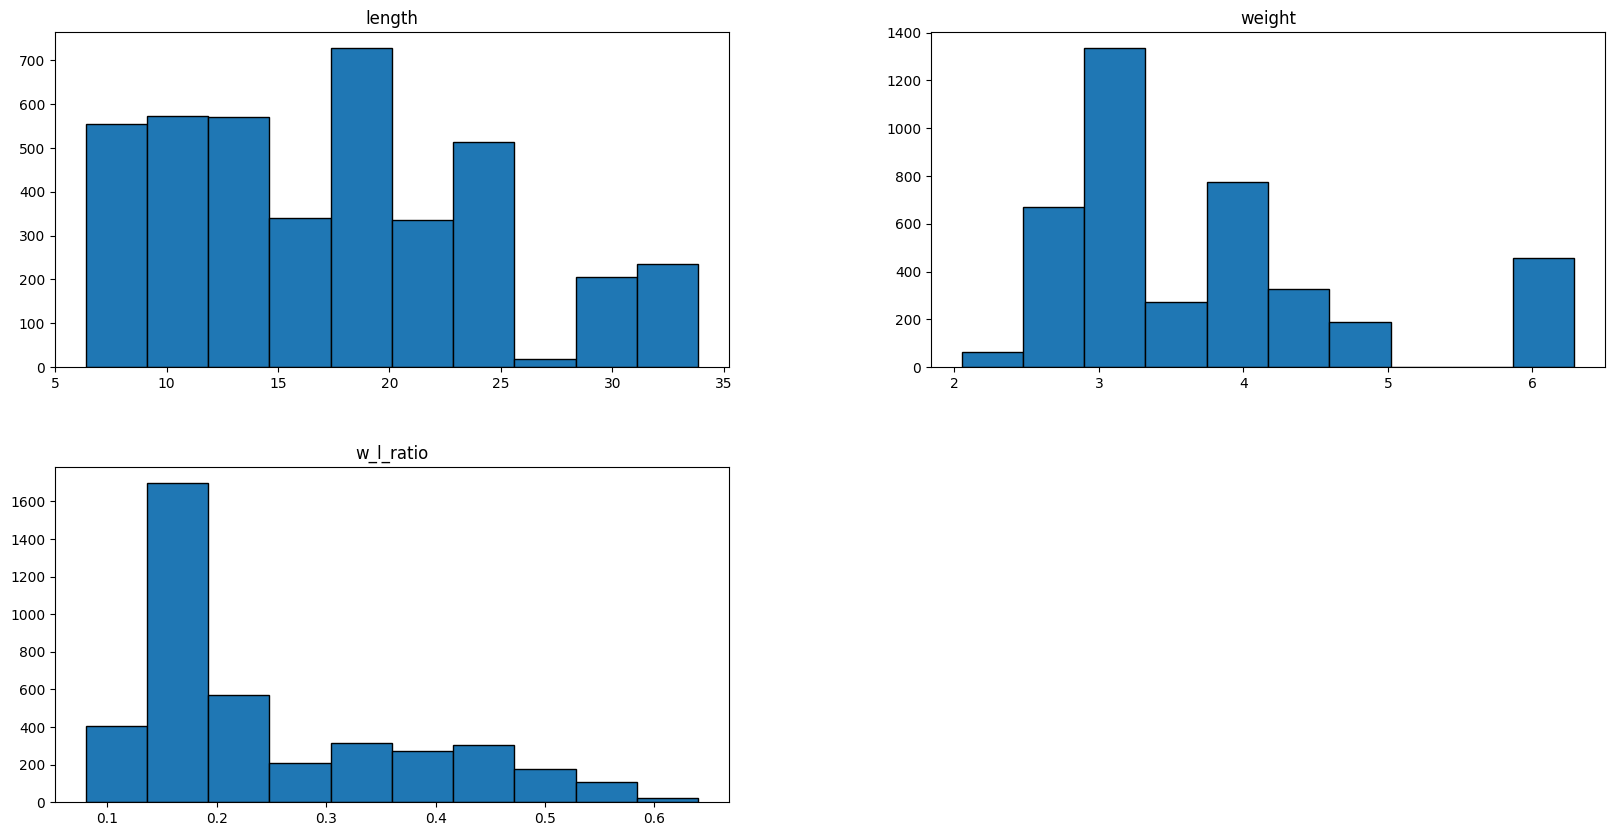

In [232]:
data.hist(figsize=(20,10), grid=False, edgecolor='black')

### Нормализация

После очистки данных и анализа статистических характеристик была проведена нормализация признаков с помощью метода MinMaxScaler

Выбор MinMaxScaler обоснован тем, что признаки датасета имеют разные диапазоны, и алгоритмы кластеризации, чувствительные к расстояниям, требуют одинакового масштаба для корректной работы. Кроме того, MinMaxScaler сохраняет относительные различия между значениями и приводит их к диапазону [0, 1], что упрощает интерпретацию и визуализацию данных.

In [233]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(data)     # numpy
scaler_data = pd.DataFrame(X_scaled, columns=data.columns)
scaler_data

,length,weight,w_l_ratio
0,0.156364,0.330189,0.428571
1,0.020000,0.287736,0.696429
2,0.073455,0.332547,0.589286
3,0.044000,0.308962,0.642857
4,0.162545,0.313679,0.410714
...,...,...,...
4075,0.880000,0.959906,0.214286
4076,0.847273,0.957547,0.232143
4077,0.961818,0.990566,0.196429
4078,0.851636,0.957547,0.232143


#### Диаграмма рассеивания
Для визуальной оценки структуры данных была построена матрица диаграмм рассеяния

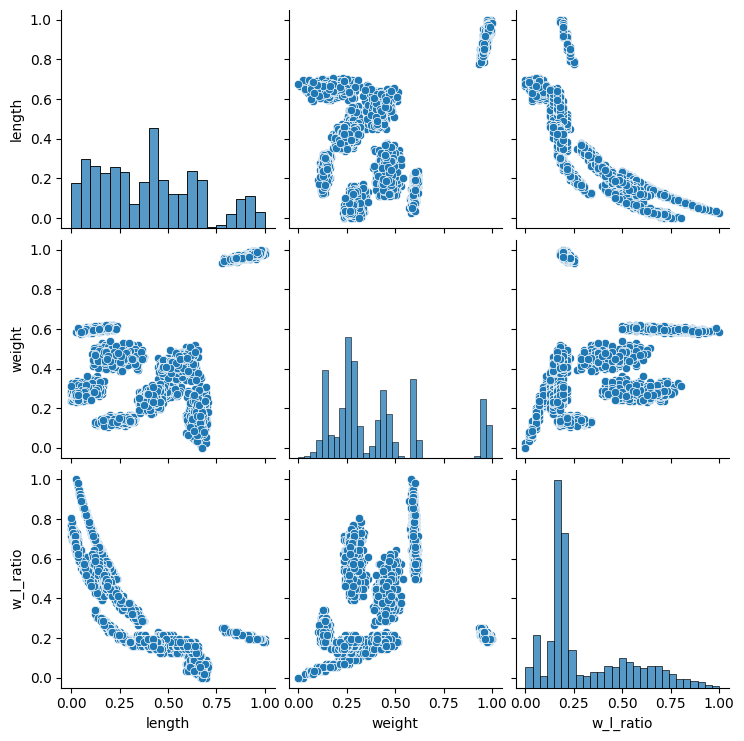

In [234]:
sns.pairplot(scaler_data)



Анализ матрицы диаграмм рассеяния показал наличие нескольких компактных групп объектов, что позволяет предположить 8 кластеров. Кластеры имеют ленточную форму, для такой формы подойдут такие методы как иерархическая кластеризация и DBSCAN.


### DBSCAN

Для метода DBSCAN оптимальные параметры — это eps (максимальное расстояние между соседними точками) и min_samples (минимальное количество точек, формирующих плотный кластер).

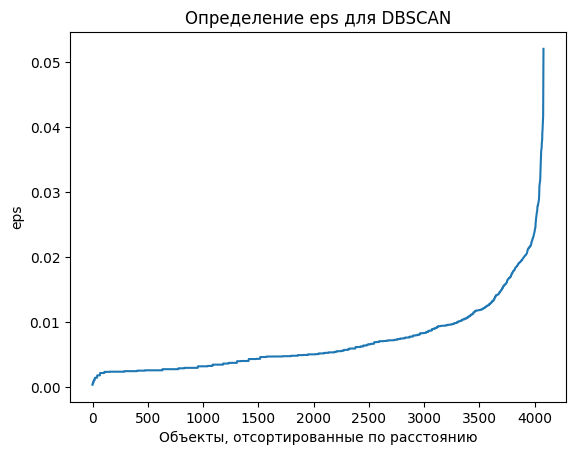

In [235]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)  # расстояние до 5-го соседа
plt.plot(distances[:,4])
plt.ylabel("eps")
plt.xlabel("Объекты, отсортированные по расстоянию")
plt.title("Определение eps для DBSCAN")
plt.show()


На графике ищут точку «излома», после которой расстояния резко возрастают, и выбирают её значение в качестве eps. Это позволяет алгоритму корректно выделять плотные кластеры и отделять шумовые точки.
Для нашего примера это точка в диапозоне от 0.01 до 0.03

Построим модель с eps = 0.03 и min_samples = 5 

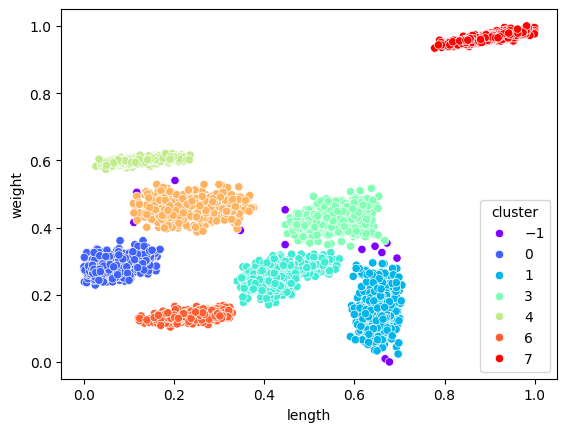

In [236]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.03, min_samples=5)

y_dbscan = dbscan.fit_predict(X_scaled)

scaler_data['cluster'] = dbscan.labels_

sns.scatterplot(x = scaler_data['length'], y=scaler_data['weight'], hue=scaler_data['cluster'], palette="rainbow")

scaler_data['cluster'].value_counts()
scaler_data.drop(columns='cluster', axis=1, inplace=True)

Кластеры с номером -1 DBSCAN определил как шум

### Иерархическая кластеризация

Для выбора оптимального числа кластеров k в иерархической кластеризации можно использовать силуэт-оценку или визуальный анализ дендрограммы.

#### Дендрограмма

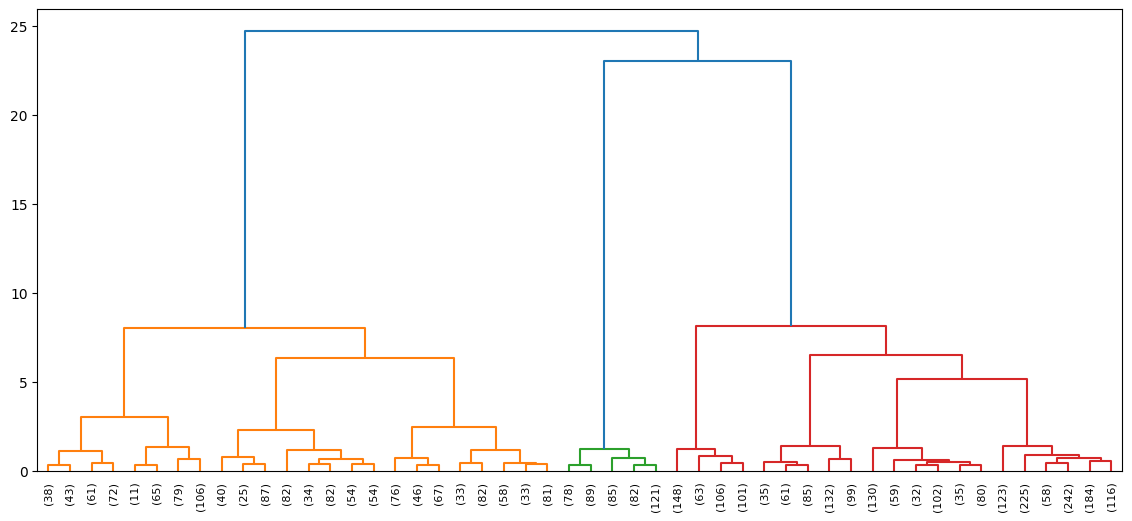

In [237]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(14, 6))
dendrogram(
    linkage(X_scaled, method='ward'),
    truncate_mode='lastp',
    p=50,
)
plt.show()

На дендограмме можно выделить 8 кластеров

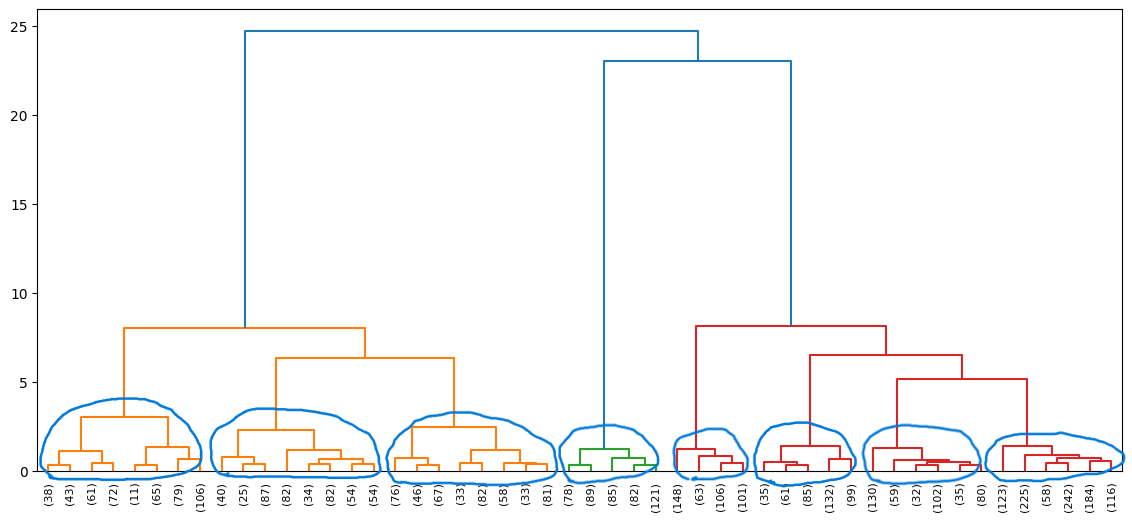

#### Силуэт



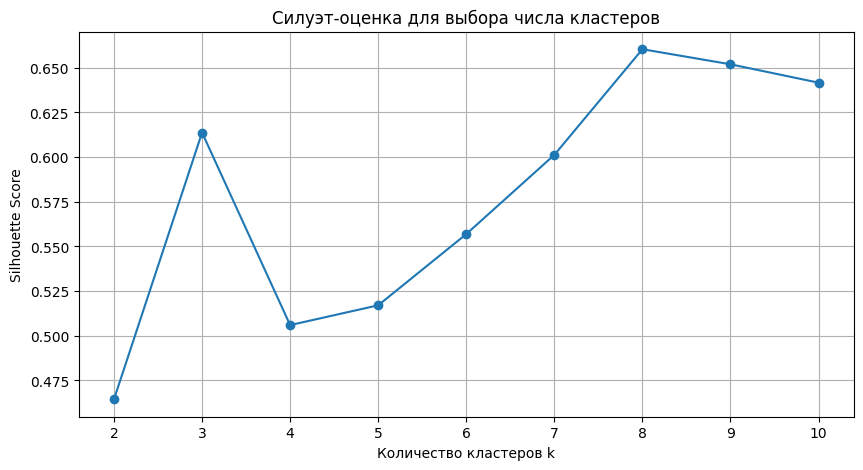

In [238]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

K_range = range(2, 11) 
silhouette = []

for k in K_range:
    ac = AgglomerativeClustering(n_clusters=k)
    labels = ac.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

plt.figure(figsize=(10,5))
plt.plot(K_range, silhouette, marker='o')
plt.title("Силуэт-оценка для выбора числа кластеров")
plt.xlabel("Количество кластеров k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()



Значение силуэта достигает максимума 0.66 при k=8, что указывает на наилучшую разделимость кластеров и высокую компактность объектов внутри них. Для меньшего числа кластеров (k=2–7) силуэт ниже, что свидетельствует о слиянии различных групп в слишком крупные кластеры. Для большего числа кластеров (k=9–10) значение силуэта слегка снижается, что отражает избыточное дробление естественных групп. Таким образом, оптимальным числом кластеров для иерархической кластеризации на данном датасете является 8.

Постоим модель с k=8

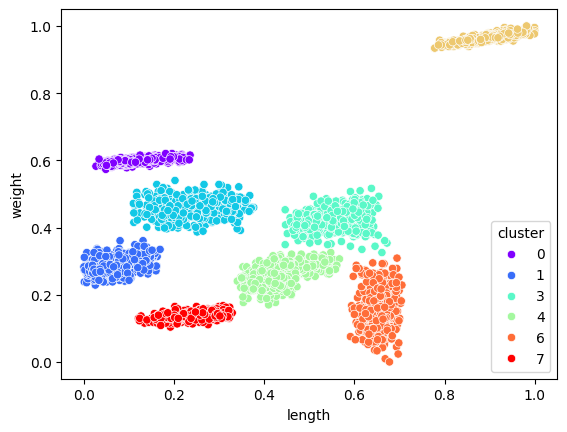

In [239]:

model_ac = AgglomerativeClustering(
    n_clusters=8,
    linkage='ward'
)


y_ac = model_ac.fit_predict(X_scaled)

scaler_data['cluster'] = model_ac.labels_

sns.scatterplot(x = scaler_data['length'], 
                y = scaler_data['weight'], 
                hue = scaler_data['cluster'], 
                palette="rainbow")

plt.show()
scaler_data['cluster'].value_counts()
scaler_data.drop(columns='cluster', axis=1, inplace=True)

### Расчет метрик качества

#### Внутренние метрики

Внутренние метрики отображают качество кластеризации только по информации в данных.

##### Компактность кластеров (Cluster Cohesion)
Идея данного метода в том, что чем ближе друг к другу находятся объекты внутри кластеров, тем лучше разделение.

Таким образом, необходимо минимизировать внутриклассовое расстояние, например, сумму квадратов отклонений:

In [240]:

def cluster_cohesion(X, labels):
    
    X = np.array(X)
    labels = np.array(labels)

    clusters = np.unique(labels)

    
    WSS = 0.0
    per_cluster_wss = {}
    for cluster in clusters:
        if (cluster == -1):
            continue
        points = X[labels == cluster]
        mean_cluster = points.mean(axis=0)
        wss = np.sum(np.linalg.norm(points - mean_cluster, axis=1)**2)
        per_cluster_wss[cluster] = float(wss)
        WSS += wss
    
    return float(WSS)



Посчитаем данную метрику для наших методов

In [241]:
wss_dbscan = cluster_cohesion(X_scaled, y_dbscan)

wss_ac =cluster_cohesion(X_scaled, y_ac)

print(wss_dbscan)

print(wss_ac)

24.453885186008037
24.81169411467676


##### Отделимость кластеров (Cluster Separation)

В данном случае идея противоположная — чем дальше друг от друга находятся объекты разных кластеров, тем лучше.

Поэтому здесь стоит задача максимизации суммы квадратов отклонений:

In [242]:
def cluster_separation(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    global_mean = X.mean(axis=0)

    clusters = np.unique(labels)

    BSS = 0.0
    per_cluster_bss = {}

    for cluster in clusters:
        if (cluster == -1):
            continue
        points = X[labels == cluster]
        mean_cluster = points.mean(axis=0)

        bss_j = np.linalg.norm(mean_cluster - global_mean)**2
        per_cluster_bss[cluster] = float(bss_j)

        BSS += bss_j

    BSS_total = n * BSS

    return float(BSS_total)

Посчитаем данную метрику для наших методов

In [243]:
bss_dbscan = cluster_separation(X_scaled, y_dbscan)

bss_ac =cluster_separation(X_scaled, y_ac)

print(bss_dbscan)

print(bss_ac)

6032.280524351517
6035.60781970059


##### Силуэт (Silhouette)

Значение силуэта показывает, насколько объект похож на свой кластер по сравнению с другими кластерами.

Чем ближе данная оценка к 1, тем лучше.

Посчитаем данную метрику для наших методов

In [244]:
from sklearn.metrics import silhouette_score

dbscan_silhouette_score = silhouette_score(X_scaled, y_dbscan)

ac_silhouette_score = silhouette_score(scaler_data, y_ac)

print(dbscan_silhouette_score)

print(ac_silhouette_score)

0.6589219263276387
0.6603614128742454


#### Внешние метрики

Внешние меры основаны на сравнении результата кластеризации с априори известным разделением на классы.

У нас есть заранее известные классы в y_true (9 кластеров)

##### Индекс Rand

Индекс Rand оценивает, насколько много из тех пар элементов, которые находились в одном классе, и тех пар элементов, которые находились в разных классах, сохранили это состояние после кластеризации алгоритмом.

Имеет область определения от 0 до 1, где 1 — полное совпадение кластеров с заданными классами, а 0 — отсутствие совпадений.

Посчитаем данную метрику для наших моделей

In [245]:
from sklearn.metrics import rand_score, pair_confusion_matrix

rand_ac = rand_score(y_true, y_ac)

rand_dbscan = rand_score(y_true, y_dbscan)

print("Rand Index Agglomerative Clustering:", rand_ac)
print("Rand Index DBSCAN:", rand_dbscan)

print("\nPair Confusion Matrix DBSCAN:")
print(pair_confusion_matrix(y_true, y_dbscan))

print("\nPair Confusion Matrix Agglomerative Clustering:")
print(pair_confusion_matrix(y_true, y_ac))

Rand Index Agglomerative Clustering: 0.9726983978195348
Rand Index DBSCAN: 0.9722243052651313

Pair Confusion Matrix DBSCAN:
[[14341558   450254]
 [   11998  1838510]]

Pair Confusion Matrix Agglomerative Clustering:
[[14339922   451890]
 [    2472  1848036]]


#### Индекс Adjusted Rand

В отличие от обычного индекса Rand, индекс Adjusted Rand может принимать отрицательные значения

Посчитаем данную метрику для наших моделей

In [246]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_ac = adjusted_rand_score(y_true, y_ac)

adjusted_rand_dbscan = adjusted_rand_score(y_true, y_dbscan)

print("Adjusted Rand Index Agglomerative Clustering:", adjusted_rand_ac)
print("Adjusted Rand Index DBSCAN:", adjusted_rand_dbscan)

Adjusted Rand Index Agglomerative Clustering: 0.8751397055870552
Adjusted Rand Index DBSCAN: 0.872667790108293


#### Индекс Жаккара (Jaccard Index)

Индекс Жаккара похож на Индекс Rand, только не учитывает пары элементов находящиеся в разные классах и разных кластерах (TN)

Имеет область определения от 0 до 1, где 1 — полное совпадение кластеров с заданными классами, а 0 — отсутствие совпадений.

Посчитаем данную метрику для наших моделей

In [247]:
from sklearn.metrics import jaccard_score

jaccard_rand_ac = jaccard_score(y_true, y_ac, average='macro')

jaccard_rand_dbscan = jaccard_score(y_true, y_dbscan, average='macro')

print("jaccard Agglomerative Clustering:", jaccard_rand_ac)
print("jaccard DBSCAN:", jaccard_rand_dbscan)

jaccard Agglomerative Clustering: 0.11035007610350075
jaccard DBSCAN: 0.6459011540388243


#### Индекс Фоулкса – Мэллова (Fowlkes-Mallows Index)

Индекс Фоулкса – Мэллова используется для определения сходства между двумя кластерами.

Более высокое значение индекса означает большее сходство между кластерами. Этот индекс также хорошо работает на зашумленных данных.

Посчитаем данную метрику для наших моделей

In [248]:
from sklearn.metrics import fowlkes_mallows_score

fm_ac = fowlkes_mallows_score(y_true, y_ac)
fm_dbscan = fowlkes_mallows_score(y_true, y_dbscan)

print("Fowlkes–Mallows Agglomerative Clustering:", fm_ac)
print("Fowlkes–Mallows DBSCAN:", fm_dbscan)

Fowlkes–Mallows Agglomerative Clustering: 0.8957937173382421
Fowlkes–Mallows DBSCAN: 0.8933466353258117


### Сравнительный анализ

In [249]:
metrics = {
    "Metric": [
        "WSS",
        "BSS",
        "Silhouette Score",
        "Rand Index",
        "Adjusted Rand Index",
        "Jaccard Index",
        "Fowlkes–Mallows Score"
    ],
    "Agglomerative Clustering": [
        wss_ac,
        bss_ac,
        ac_silhouette_score,
        rand_ac,
        adjusted_rand_ac,
        jaccard_rand_ac,
        fm_ac
    ],
    "DBSCAN": [
        wss_dbscan,
        bss_dbscan,
        dbscan_silhouette_score,
        rand_dbscan,
        adjusted_rand_dbscan,
        jaccard_rand_dbscan,
        fm_dbscan
    ]
}

metrics_df = pd.DataFrame(metrics)

metrics_df

,Metric,Agglomerative Clustering,DBSCAN
0,WSS,24.811694,24.453885
1,BSS,6035.607820,6032.280524
2,Silhouette Score,0.660361,0.658922
3,Rand Index,0.972698,0.972224
4,Adjusted Rand Index,0.875140,0.872668
5,Jaccard Index,0.110350,0.645901
6,Fowlkes–Mallows Score,0.895794,0.893347


Оба алгоритма кластеризации — DBSCAN и Agglomerative Clustering — демонстрируют высокое качество разделения данных. По компактности кластеров WSS у DBSCAN составляет 24.45 против 24.81 у Agglomerative, что говорит о чуть более плотных кластерах у DBSCAN. Межклассовой разброс BSS чуть выше у Agglomerative (6035.61 против 6032.28), значит центры кластеров у него чуть дальше друг от друга. Silhouette Score близок: 0.6604 для Agglomerative и 0.6589 для DBSCAN, что подтверждает схожую структуру кластеров.

Метрики совпадения с эталонными метками также высоки: Rand Index 0.9727 (Agglomerative) и 0.9722 (DBSCAN), Adjusted Rand Index 0.8751 и 0.8727 соответственно, Fowlkes–Mallows Score 0.8958 и 0.8933. При этом Jaccard Index значительно выше у DBSCAN — 0.646 против 0.110 у Agglomerative, что указывает на более точное выделение пар объектов одного класса.

Таким образом, DBSCAN чуть выигрывает по точности соответствия меткам, а Agglomerative — по разнесённости центров кластеров, при этом оба метода показывают очень хорошие результаты.

### Влияние параметров на качество медота DBSCSAN

Исследуем влияние eps и min_samples:

In [250]:

results = []

for min_samples in range(2,6):
    for eps in range(1,31):
        eps_val = eps / 100   
        model_db = DBSCAN(eps=eps_val, min_samples=min_samples)

        y_pred = model_db.fit_predict(X_scaled)

        n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)

        wss = cluster_cohesion(X_scaled, y_pred)
        bss = cluster_separation(X_scaled, y_pred)
        silhouette = silhouette_score(X_scaled, y_pred)
        rand = rand_score(y_true, y_pred)
        ari = adjusted_rand_score(y_true, y_pred)
        jaccard = jaccard_score(y_true, y_pred, average='macro')
        fm = fowlkes_mallows_score(y_true, y_pred)

        results.append({
            'eps': eps_val,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'WSS': wss,
            'BSS': bss,
            'Silhouette': silhouette,
            'Rand Index': rand,
            'Adjusted Rand': ari,
            'Jaccard': jaccard,
            'Fowlkes-Mallows': fm
        })


results_df = pd.DataFrame(results)




        

,eps,min_samples,n_clusters,WSS,BSS,Silhouette,Rand Index,Adjusted Rand,Jaccard,Fowlkes-Mallows
62,0.03,4,8,24.602920,6033.078840,0.658124,0.972391,0.873504,0.646556,0.894147
92,0.03,5,8,24.453885,6032.280524,0.658922,0.972224,0.872668,0.645901,0.893347
32,0.03,3,8,24.624496,6033.550412,0.658888,0.972339,0.873290,0.498336,0.893979
2,0.03,2,9,24.624585,7359.599291,0.632670,0.972340,0.873293,0.397181,0.893981
63,0.04,4,5,92.818609,4730.028755,0.555360,0.764152,0.381069,0.131919,0.566041
93,0.04,5,5,92.818609,4730.028755,0.555360,0.764152,0.381069,0.131919,0.566041
33,0.04,3,5,92.818609,4730.028755,0.555360,0.764152,0.381069,0.131919,0.566041
3,0.04,2,5,92.818609,4730.028755,0.555360,0.764152,0.381069,0.131919,0.566041
91,0.02,5,11,22.287546,9729.962546,0.479007,0.967807,0.849878,0.080007,0.871465
64,0.05,4,4,112.967659,4159.936490,0.563148,0.737953,0.347215,0.077434,0.545814


In [253]:
best_results = results_df.sort_values(by='Fowlkes-Mallows', ascending=False).head(10)
best_results

,eps,min_samples,n_clusters,WSS,BSS,Silhouette,Rand Index,Adjusted Rand,Jaccard,Fowlkes-Mallows
62,0.03,4,8,24.602920,6033.078840,0.658124,0.972391,0.873504,0.646556,0.894147
2,0.03,2,9,24.624585,7359.599291,0.632670,0.972340,0.873293,0.397181,0.893981
32,0.03,3,8,24.624496,6033.550412,0.658888,0.972339,0.873290,0.498336,0.893979
92,0.03,5,8,24.453885,6032.280524,0.658922,0.972224,0.872668,0.645901,0.893347
1,0.02,2,23,22.701795,16040.829249,0.192928,0.969114,0.856348,0.040266,0.877430
31,0.02,3,14,22.701370,11623.061584,0.454865,0.969056,0.856125,0.064426,0.877265
61,0.02,4,14,22.502959,11674.309200,0.451972,0.968568,0.853630,0.064286,0.874912
91,0.02,5,11,22.287546,9729.962546,0.479007,0.967807,0.849878,0.080007,0.871465
3,0.04,2,5,92.818609,4730.028755,0.555360,0.764152,0.381069,0.131919,0.566041
33,0.04,3,5,92.818609,4730.028755,0.555360,0.764152,0.381069,0.131919,0.566041


Анализ таблицы показывает, что параметры DBSCAN сильно влияют на структуру кластеров и качество кластеризации. При малых значениях eps, например 0.02, формируется большое количество кластеров (11–23), при этом Silhouette Score низкий (0.19–0.48), а совпадение с истинными метками по Adjusted Rand и Jaccard также невысокое, что указывает на чрезмерное дробление данных. При eps=0.03 количество кластеров стабилизируется на уровне 8–9, Silhouette Score повышается до 0.63–0.66, Adjusted Rand достигает ≈0.87, а Jaccard — 0.50–0.65, что говорит о более компактных кластерах и хорошем соответствии с истинными метками. Увеличение eps до 0.04 резко снижает количество кластеров до 5 и ухудшает показатели совпадения с эталонными метками, хотя Silhouette Score остаётся умеренно высоким.

Влияние min_samples проявляется в том, что при небольших значениях (2–3) формируется больше мелких кластеров, тогда как увеличение min_samples до 4–5 уменьшает количество кластеров, улучшает Silhouette Score и повышает Jaccard до максимума около 0.65. Слишком высокое min_samples может объединять кластеры и превращать части данных в шум.

Оптимальные параметры для твоих данных — eps ≈ 0.03 и min_samples ≈ 4, при которых формируется 8 кластеров с хорошей компактностью и высокой согласованностью с истинными метками (Silhouette ≈ 0.658, Adjusted Rand ≈ 0.873, Jaccard ≈ 0.646, Fowlkes-Mallows ≈ 0.894). В целом, увеличение eps уменьшает количество кластеров, а повышение min_samples улучшает их стабильность и точность соответствия меткам, поэтому эти два параметра должны подбираться совместно для оптимальной кластеризации.

### Визуализация кластеров

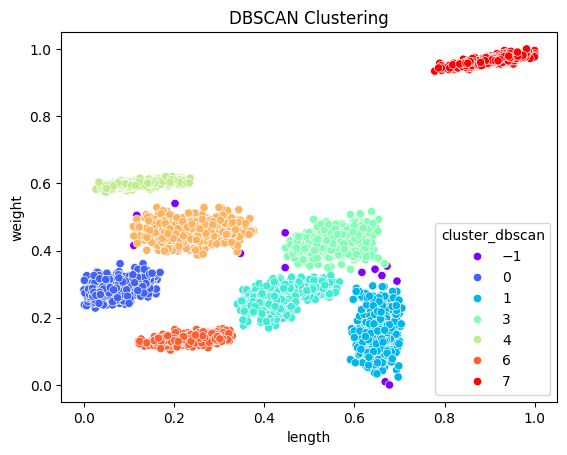

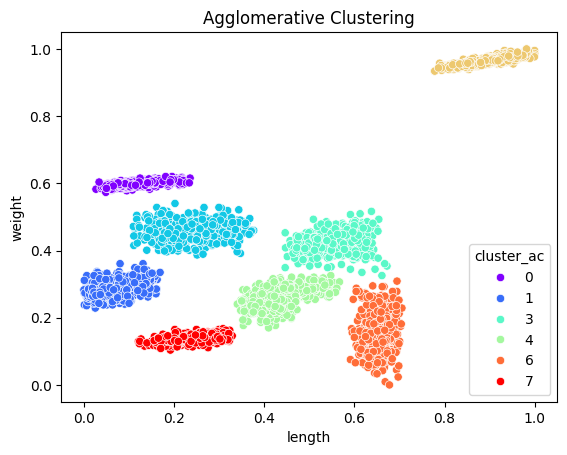

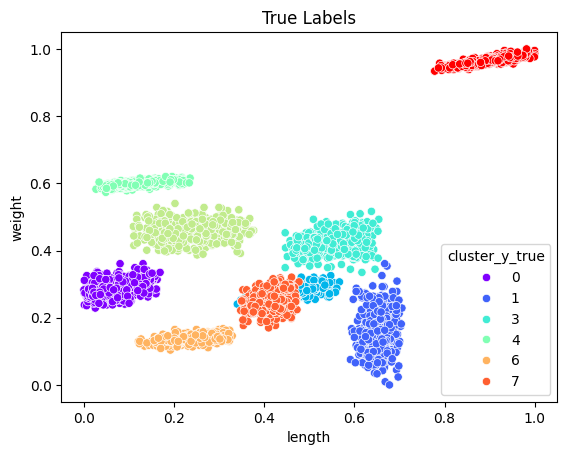

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

scaler_data['cluster_dbscan'] = dbscan.labels_
sns.scatterplot(
    data=scaler_data,
    x='length',
    y='weight',
    hue='cluster_dbscan',
    palette="rainbow"
)
plt.title("DBSCAN Clustering")
plt.show()


scaler_data['cluster_ac'] = model_ac.labels_
sns.scatterplot(
    data=scaler_data,
    x='length',
    y='weight',
    hue='cluster_ac',
    palette="rainbow"
)
plt.title("Agglomerative Clustering")
plt.show()

scaler_data['cluster_y_true'] = y_true
sns.scatterplot(
    data=scaler_data,
    x='length',
    y='weight',
    hue='cluster_y_true',
    palette="rainbow"
)
plt.title("True Labels")
plt.show()


Оба метода кластеризации — DBSCAN и агломеративная кластеризация — выявили в данных чётко разделённые компактные группы объектов, что хорошо подтверждается визуализацией в пространстве признаков (length, weight). Несмотря на различия алгоритмов, полученные кластеры почти полностью совпадают по форме и расположению с истинными метками. DBSCAN успешно выделил плотные группы и корректно определил несколько выбросов (обозначенных как «–1»), тогда как агломеративная кластеризация жёстко распределила все точки между кластерами, не выделяя шум. При этом структуру групп оба метода восстанавливают практически идентично: каждая группа представляет собой компактное облако с чёткими границами, что характерно для хорошо разделимых данных. Кластеры можно интерпретировать как объединения объектов со схожими значениями длины и веса: некоторые группы содержат небольшие и лёгкие объекты, другие — средние или более крупные. Такой характер распределения подтверждается и центрами кластеров (в случае K-means), которые располагаются в типичных зонах плотности данных и отражают среднее положение каждой группы. В целом, результаты показывают, что данные обладают ярко выраженной кластерной структурой, одинаково хорошо выявляемой разными методами, а отличие между алгоритмами заключается главным образом в обращении с шумом и выборе числа кластеров.